```
1. split passengerid and cabin, drop names ✔️
2. cleaning data: impute contextual missing values first ✔️
3. plot heatmap for numerical features and bar charts for non-numerical features ✔️
4. drop, encode and scale features ✔️
5. split train into train and val 80/20 ✔️
6. logistic regression and accuracy ✔️
7. adding dropped features and checking if it improves accuracy ✔️
```

In [10]:
import pandas as pd
import numpy as np

train = pd.read_csv("data/train.csv")

In [11]:
# 1
train["Transported"] = train["Transported"].astype(int)

# split passengerid
train["Group"], train["GroupNum"] = train["PassengerId"].str.split("_").str[0], train["PassengerId"].str.split("_").str[1]

# split cabin ABCDEFG/num/PS
train[["CabinDeck", "CabinNum", "CabinSide"]] = train["Cabin"].str.split("/", expand=True)
train["CabinNum"] = train["CabinNum"].astype(float)

train.drop(["PassengerId", "Cabin", "Name"], axis=1, inplace=True)

train.head()

,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,Group,GroupNum,CabinDeck,CabinNum,CabinSide
0,Europa,False,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,0,0001,01,B,0.0,P
1,Earth,False,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,1,0002,01,F,0.0,S
2,Europa,False,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,0,0003,01,A,0.0,S
3,Europa,False,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,0,0003,02,A,0.0,S
4,Earth,False,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,1,0004,01,F,1.0,S


In [12]:
# 2
print("before")
print(train.isnull().sum())
print()

# if homeplanet/destination/cabindeck/cabinnum empty, fill with mode of passenger travel group
for col in ["CabinDeck", "CabinSide", "HomePlanet", "Destination"]:
    group_mode = train.groupby("Group")[col].agg(lambda x: x.mode()[0] if x.notna().any() else np.nan)
    train[col] = train[col].fillna(train["Group"].map(group_mode))
    train[col] = train[col].fillna(train[col].mode()[0]) # if still null, fill with mode

spending_features = ["RoomService", "FoodCourt",  "ShoppingMall", "Spa", "VRDeck"]
# if cryosleep true, spending is 0.0
train.loc[ train["CryoSleep"] == True, spending_features ] = 0.0
# if spending not 0.0, cryosleep false
train.loc[ train[spending_features].sum(axis=1) > 0, "CryoSleep" ] = False
train["CryoSleep"] = train["CryoSleep"].fillna(train["CryoSleep"].mode()[0]) # if still null, fill with mode

# if age or spending empty, fill median
numerical_features = spending_features + ["Age"]
train[numerical_features] = train[numerical_features].fillna(train[numerical_features].median())

# if vip empty, fill mode
train["VIP"] = train["VIP"].fillna(train["VIP"].mode()[0])

# if cabinnum empty, fill with median
train["CabinNum"] = train["CabinNum"].fillna(train["CabinNum"].median())

print("after")
print(train.isnull().sum())

before
HomePlanet      201
CryoSleep       217
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Transported       0
Group             0
GroupNum          0
CabinDeck       199
CabinNum        199
CabinSide       199
dtype: int64

after
HomePlanet      0
CryoSleep       0
Destination     0
Age             0
VIP             0
RoomService     0
FoodCourt       0
ShoppingMall    0
Spa             0
VRDeck          0
Transported     0
Group           0
GroupNum        0
CabinDeck       0
CabinNum        0
CabinSide       0
dtype: int64


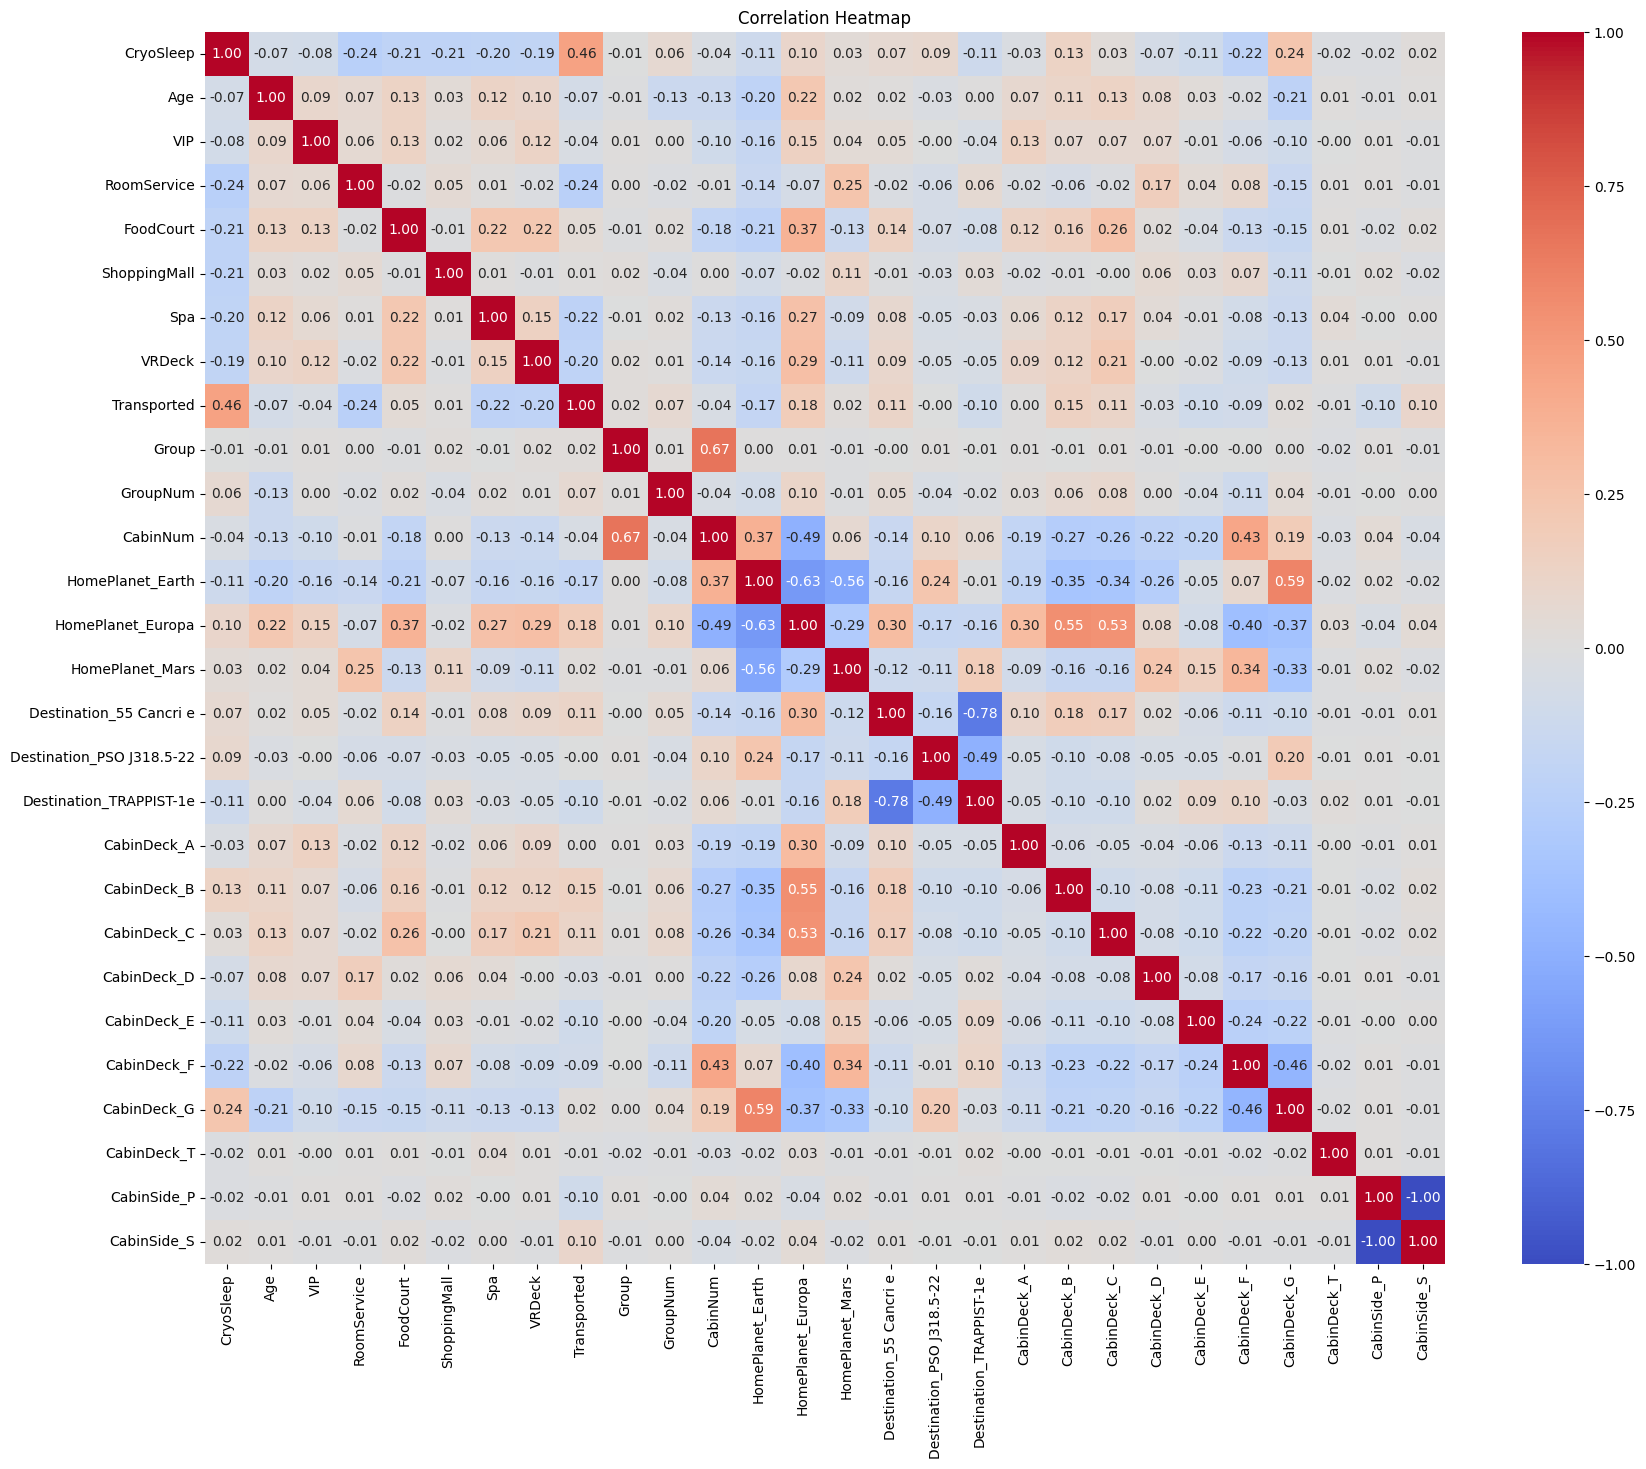

In [13]:
# 3
import seaborn as sns
import matplotlib.pyplot as plt

# encode boolean features
train["CryoSleep"] = train["CryoSleep"].astype(int)
train["VIP"] = train["VIP"].astype(int)
train["Transported"] = train["Transported"].astype(int)
train[["Group", "GroupNum"]] = train[["Group", "GroupNum"]].astype(int)

# one hot encode categorical features
train = pd.get_dummies(train, columns=["HomePlanet", "Destination", "CabinDeck", "CabinSide"])

# heatmap of all features
plt.figure(figsize=(20, 16))
sns.heatmap(train.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [14]:
# 4
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

X = train.drop("Transported", axis=1)
y = train["Transported"]

# scale numerical features first
float_cols = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck", "Age", "CabinNum"]
scaler = StandardScaler()
X[float_cols] = scaler.fit_transform(X[float_cols])

# then use RFE to select best 15 features
model = LogisticRegression(max_iter=5000)
rfe = RFE(model, n_features_to_select=15)
rfe.fit(X, y)

# get selected feature names
features_to_keep = X.columns[rfe.support_].tolist()
print("Selected features:", features_to_keep)

X = X[features_to_keep]

Selected features: ['CryoSleep', 'VIP', 'RoomService', 'FoodCourt', 'Spa', 'VRDeck', 'HomePlanet_Earth', 'HomePlanet_Europa', 'Destination_55 Cancri e', 'CabinDeck_A', 'CabinDeck_B', 'CabinDeck_C', 'CabinDeck_E', 'CabinDeck_G', 'CabinSide_P']


In [ ]:
# 5 
from sklearn.model_selection import train_test_split

y = train["Transported"]
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
# 6 
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

# train
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# evaluate
y_pred = model.predict(X_val)
print("Accuracy:", accuracy_score(y_val, y_pred))
print("F1 Score:", f1_score(y_val, y_pred))

Accuracy: 0.7797584818861415
F1 Score: 0.7863915225878416
